# Extended CNN training

Seven 1D-CNN variants test different assumptions about biological time courses. Model selection, classification reports and confusion matrices use only the fixed `validate` fold (called *tune* here); `test` is not loaded in this notebook.

## Contents and architecture map

The links point directly to the corresponding notebook section. The schemas show the main information path; every encoder is followed by a regularized dense classification head.

| Section | Inductive bias | Compact schema | Saved artifact |
|---|---|---|---|
| [First-Difference](#variant-first-difference) | Levels and local slopes are complementary | `x → CNN ┐`<br>`Δx → CNN ┴→ concat → head` | `extended_cnn_first_difference` |
| [FFT](#variant-fft) | Global frequency content complements time-local features | `x, Δx, log |rFFT(x)| → CNNs → concat → head` | `extended_cnn_fft` |
| [Gated fusion](#variant-gated-fusion) | Learn per-feature reliance on raw values versus derivatives | `f = g·f_raw + (1−g)·f_Δ → head` | `extended_cnn_gated_fusion` |
| [Multi-scale CNN](#variant-multi-scale) | Short and long motifs should be detected in parallel | `Conv(k=3/7/15) → concat → head` | `extended_cnn_multi_scale` |
| [TCN](#variant-tcn) | Dilations provide a large temporal receptive field | `dilated residual blocks d=1/2/4 → GAP → head` | `extended_cnn_tcn` |
| [Shift-robust CNN](#variant-shift-robust) | Small temporal shifts should affect predictions less | `stride-1 CNN → global average pooling → head` | `extended_cnn_shift_robust` |
| [Ordinal classification](#variant-ordinal) | Dose classes have a known order | `CNN → latent dose score → ordered centers → logits` | `extended_cnn_ordinal` |
| [Direct comparison](#direct-comparison) | Select by tune macro-F1 and tune loss | metrics and parameter count | — |
| [History comparison](#training-history-comparison) | Diagnose under/overfitting across all variants | four synchronized panels | — |

<a id="setup"></a>
## 1. Setup and fixed folds

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from pytorch_timecourse_classification.analysis import (
    plot_history_comparison, plot_training_history, summarize_history,
)
from pytorch_timecourse_classification.artifacts import (
    artifact_dir_for, load_model, save_experiment_artifacts,
)
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.models.extended_cnns import ExtendedCNNClassifier
from pytorch_timecourse_classification.training import TrainingConfig, train

In [2]:
train_fold, tune_fold, preprocessor = load_training_folds()
class_labels = np.arange(len(preprocessor.class_names))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for fold_name, fold in (("train", train_fold), ("tune", tune_fold)):
    counts = np.bincount(fold.targets.numpy(), minlength=len(class_labels))
    print(f"{fold_name:>5}: {tuple(fold.features.shape)}, {dict(zip(preprocessor.class_names, counts))}")
print(f"device: {device}")

train: (2790, 1, 289), {'0pM': np.int64(286), '1pM': np.int64(621), '2.5pM': np.int64(533), '5pM': np.int64(487), '25pM': np.int64(581), '100pM': np.int64(282)}
 tune: (349, 1, 289), {'0pM': np.int64(36), '1pM': np.int64(78), '2.5pM': np.int64(66), '5pM': np.int64(62), '25pM': np.int64(72), '100pM': np.int64(35)}
device: cuda


In [3]:
def create_model(architecture, **config):
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    model = ExtendedCNNClassifier(
        input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names),
        architecture=architecture,
        **config,
    )
    parameter_count = sum(
        parameter.numel() for parameter in model.parameters()
        if parameter.requires_grad
    )
    print("model_config:", model.model_config)
    print(f"trainable parameters: {parameter_count:,}")
    return model, parameter_count


def fit_model(model, training_config):
    print(f"training_config: {training_config}")
    return train(
        model, train_fold.features, train_fold.targets,
        tune_fold.features, tune_fold.targets,
        config=training_config, device=device,
    )


def analyze_history(history):
    summary = summarize_history(history)
    print(summary)
    plot_training_history(history)
    return summary


def evaluate_tune(model):
    model.eval()
    with torch.no_grad():
        predictions = model(tune_fold.features.to(device)).argmax(dim=1).cpu().numpy()
    report = classification_report(
        tune_fold.targets.numpy(), predictions, labels=class_labels,
        target_names=preprocessor.class_names, zero_division=0, output_dict=True,
    )
    print(classification_report(
        tune_fold.targets.numpy(), predictions, labels=class_labels,
        target_names=preprocessor.class_names, zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        tune_fold.targets.numpy(), predictions, labels=class_labels,
        display_labels=preprocessor.class_names, xticks_rotation=35, cmap="Blues",
    )
    plt.tight_layout()
    return {"tune_macro_f1": report["macro avg"]["f1-score"]}


def save_and_verify(experiment_name, model, history):
    paths = save_experiment_artifacts(
        artifact_dir_for(experiment_name), model=model, history=history,
        preprocessor=preprocessor, training_targets=train_fold.targets,
        validation_targets=tune_fold.targets, device=device,
    )
    reloaded_model, checkpoint = load_model(paths.model, device=device)
    print(paths)
    print(f"reloaded {checkpoint['model_name']} at best epoch {checkpoint['best_epoch']}")
    return reloaded_model, paths


COMMON_MODEL_CONFIG = {
    "branch_channels": (24, 48, 64),
    "kernel_sizes": (9, 7, 5),
    "dilations": (1, 2, 4),
    "hidden_dims": (128, 32),
    "dropout": 0.30,
    "adaptive_pool_size": 4,
}

def training_config(*, balance="weighted_loss", learning_rate=5e-4, weight_decay=5e-4):
    return TrainingConfig(
        epochs=140, batch_size=256, learning_rate=learning_rate,
        weight_decay=weight_decay, scheduler_step_size=15,
        learning_rate_decay=0.80, patience=20,
        class_balance_strategy=balance,
    )

<a id="variant-first-difference"></a>
## 2. First-Difference CNN

The raw branch learns absolute signal levels and shapes; the derivative branch sees `Δx[t] = x[t+1] − x[t]` and emphasizes rises, falls and turning points. Concatenation preserves both views instead of forcing one representation to replace the other.

```text
raw x ─────────→ residual/dilated CNN ─┐
Δx = x[t+1]-x[t] → residual/dilated CNN ─┴→ concatenate → MLP → dose
```

### 2.1 Model generation

In [4]:
first_difference_model, first_difference_parameter_count = create_model(
    "first_difference", **COMMON_MODEL_CONFIG
)
first_difference_training_config = training_config()

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'first_difference', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 127,174


### 2.2 Training

In [5]:
first_difference_history = fit_model(
    first_difference_model, first_difference_training_config
)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0005, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.56135, validation loss 1.73706, train accuracy 36.8%, validation accuracy 28.1%
epoch   5: train loss 1.09211, validation loss 1.13108, train accuracy 57.8%, validation accuracy 53.3%
epoch  10: train loss 0.96539, validation loss 1.01315, train accuracy 60.6%, validation accuracy 57.9%
epoch  15: train loss 0.86773, validation loss 0.93355, train accuracy 63.1%, validation accuracy 63.9%
epoch  20: train loss 0.81768, validation loss 0.85860, train accuracy 66.6%, validation accuracy 65.3%
epoch  25: train loss 0.76392, validation loss 0.83499, train accuracy 68.6%, validation accuracy 67.0%
epoch  30: train loss 0.71462, validation loss 0.79491, train accuracy 71.0%, validation accuracy 65.6%
epoch  35: 

### 2.3 History analysis

This is the reference for the extensions below. Parallel high train/tune losses suggest underfitting; a falling train loss with deteriorating tune loss suggests overfitting.

{'epochs_run': 86, 'best_epoch': 66, 'training_loss': 0.5598273467846668, 'tune_loss': 0.7143395594334534, 'training_accuracy': 0.7519713261648745, 'tune_accuracy': 0.6848137535816619, 'accuracy_gap': 0.06715757258321264}


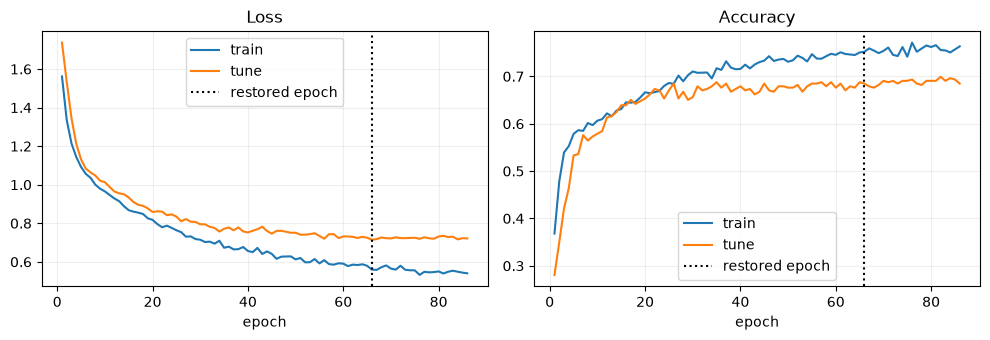

In [6]:
first_difference_summary = analyze_history(first_difference_history)

### 2.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.92      0.61        36
         1pM       0.68      0.53      0.59        78
       2.5pM       0.69      0.55      0.61        66
         5pM       0.67      0.65      0.66        62
        25pM       0.86      0.82      0.84        72
       100pM       0.86      0.86      0.86        35

    accuracy                           0.68       349
   macro avg       0.70      0.72      0.69       349
weighted avg       0.71      0.68      0.69       349



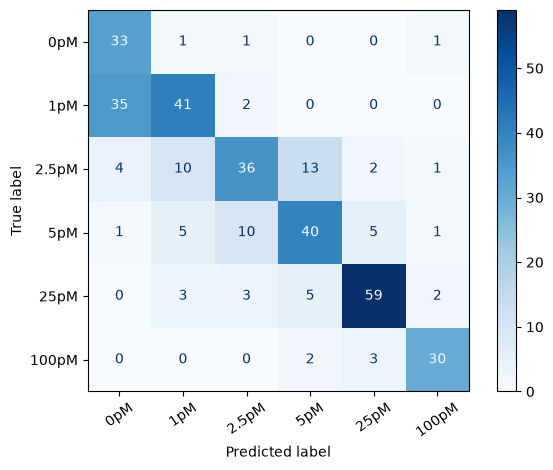

In [7]:
first_difference_tune_metrics = evaluate_tune(first_difference_model)

### 2.5 Saving artifacts

In [8]:
first_difference_reloaded, first_difference_paths = save_and_verify(
    "extended_cnn_first_difference", first_difference_model, first_difference_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_first_difference/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_first_difference/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_first_difference/metadata.json'))
reloaded extended_cnn at best epoch 66


<a id="variant-fft"></a>
## 3. FFT CNN

A third branch receives `log1p(abs(rFFT(x)))`. It directly exposes slow versus fast variation and periodicity, but magnitude discards phase and temporal localization. Keeping the raw and derivative branches prevents the spectrum from becoming the only view.

```text
x ───────────────→ CNN ─┐
Δx ──────────────→ CNN ─┼→ concatenate → MLP → dose
log(1+|rFFT(x)|) → CNN ─┘
```

### 3.1 Model generation

In [9]:
fft_model, fft_parameter_count = create_model(
    "fft", **{**COMMON_MODEL_CONFIG, "dropout": 0.35}
)
fft_training_config = training_config(
    balance="balanced_sampler", learning_rate=4e-4, weight_decay=7e-4
)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'fft', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.35, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 188,374


### 3.2 Training

In [10]:
fft_history = fit_model(fft_model, fft_training_config)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0004, weight_decay=0.0007, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='balanced_sampler', gradient_clip_norm=1.0)
epoch   1: train loss 1.70995, validation loss 1.75066, train accuracy 28.0%, validation accuracy 37.0%
epoch   5: train loss 1.22667, validation loss 1.24361, train accuracy 58.2%, validation accuracy 52.7%
epoch  10: train loss 1.06735, validation loss 1.09536, train accuracy 62.3%, validation accuracy 60.5%
epoch  15: train loss 0.99202, validation loss 1.03692, train accuracy 63.7%, validation accuracy 61.0%
epoch  20: train loss 0.91366, validation loss 0.98975, train accuracy 66.9%, validation accuracy 64.2%
epoch  25: train loss 0.84163, validation loss 0.94383, train accuracy 70.4%, validation accuracy 64.5%
epoch  30: train loss 0.84860, validation loss 0.88696, train accuracy 67.8%, validation accuracy 63.3%
epoch  3

### 3.3 History analysis

The FFT branch is useful only if tune macro-F1 or tune loss improves. A train-only gain means the extra representation mostly added variance.

{'epochs_run': 110, 'best_epoch': 90, 'training_loss': 0.6288655778840452, 'tune_loss': 0.7544023775439549, 'training_accuracy': 0.7602150537634409, 'tune_accuracy': 0.673352435530086, 'accuracy_gap': 0.08686261823335495}


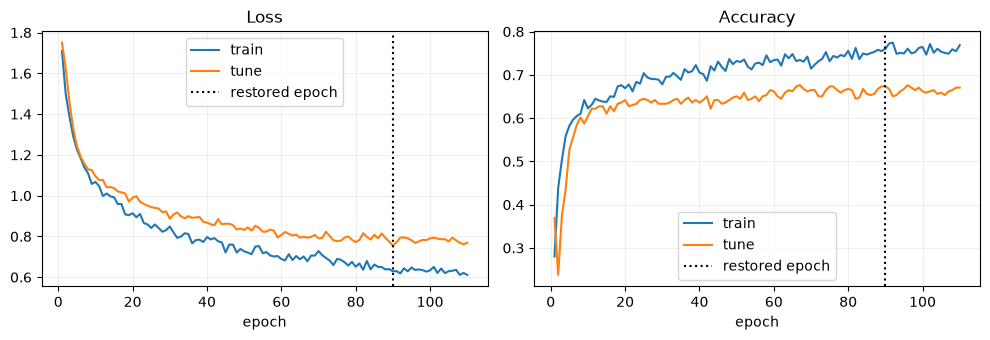

In [11]:
fft_summary = analyze_history(fft_history)

### 3.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.92      0.61        36
         1pM       0.66      0.51      0.58        78
       2.5pM       0.70      0.53      0.60        66
         5pM       0.63      0.65      0.64        62
        25pM       0.85      0.79      0.82        72
       100pM       0.86      0.86      0.86        35

    accuracy                           0.67       349
   macro avg       0.69      0.71      0.68       349
weighted avg       0.70      0.67      0.67       349



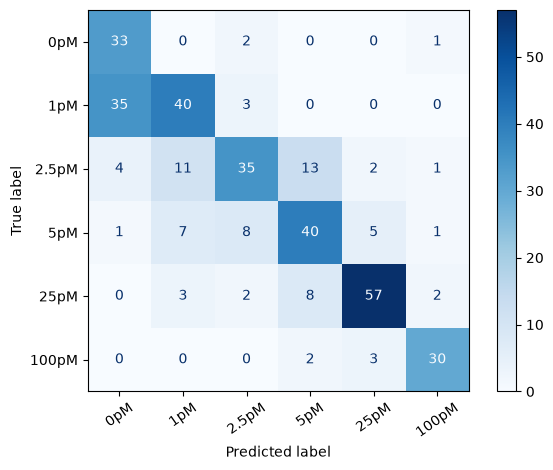

In [12]:
fft_tune_metrics = evaluate_tune(fft_model)

### 3.5 Saving artifacts

In [13]:
fft_reloaded, fft_paths = save_and_verify(
    "extended_cnn_fft", fft_model, fft_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_fft/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_fft/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_fft/metadata.json'))
reloaded extended_cnn at best epoch 90


<a id="variant-gated-fusion"></a>
## 4. Gated raw/derivative fusion

Raw and derivative encoders produce equally sized feature vectors. A learned sigmoid gate chooses continuously, feature by feature, how much of each representation to retain. This is more selective than unconditional concatenation, but the gate can overfit or collapse to one branch.

```text
f_raw ─┐                 ┌→ g·f_raw
       ├→ sigmoid gate g ┤          ├→ sum → MLP → dose
f_Δ ───┘                 └→ (1-g)·f_Δ
```

### 4.1 Model generation

In [14]:
gated_model, gated_parameter_count = create_model(
    "gated_fusion", **COMMON_MODEL_CONFIG
)
gated_training_config = training_config(weight_decay=7e-4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'gated_fusion', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 225,734


### 4.2 Training

In [15]:
gated_history = fit_model(gated_model, gated_training_config)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0005, weight_decay=0.0007, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.69421, validation loss 1.75294, train accuracy 31.5%, validation accuracy 22.3%
epoch   5: train loss 1.11705, validation loss 1.16221, train accuracy 56.9%, validation accuracy 51.6%
epoch  10: train loss 0.97893, validation loss 1.04181, train accuracy 60.6%, validation accuracy 57.9%
epoch  15: train loss 0.88450, validation loss 0.94988, train accuracy 63.9%, validation accuracy 61.3%
epoch  20: train loss 0.83473, validation loss 0.88259, train accuracy 66.7%, validation accuracy 65.6%
epoch  25: train loss 0.77493, validation loss 0.82784, train accuracy 69.1%, validation accuracy 67.9%
epoch  30: train loss 0.72175, validation loss 0.79799, train accuracy 70.2%, validation accuracy 67.9%
epoch  35: 

### 4.3 History analysis

Compare against First-Difference: a lower parameter count or smaller train–tune gap with similar macro-F1 supports selective fusion; a rapid train-only gain suggests an overly flexible gate.

{'epochs_run': 87, 'best_epoch': 67, 'training_loss': 0.5462422365783364, 'tune_loss': 0.7255307678506846, 'training_accuracy': 0.7620071684587814, 'tune_accuracy': 0.6876790830945558, 'accuracy_gap': 0.07432808536422553}


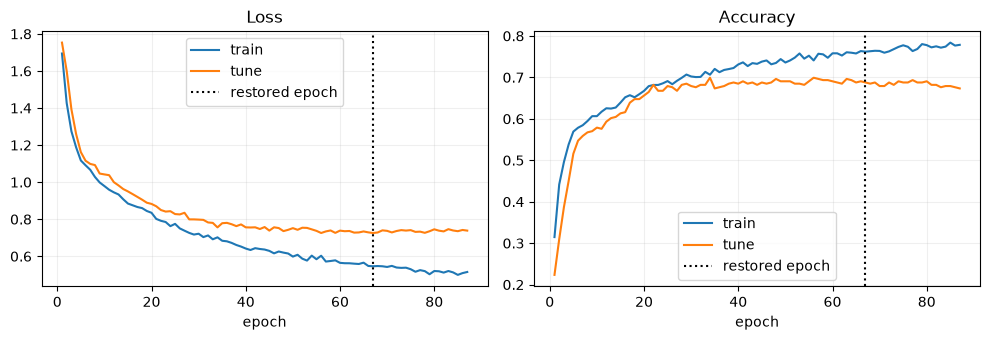

In [16]:
gated_summary = analyze_history(gated_history)

### 4.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.92      0.61        36
         1pM       0.69      0.51      0.59        78
       2.5pM       0.64      0.53      0.58        66
         5pM       0.71      0.66      0.68        62
        25pM       0.85      0.83      0.84        72
       100pM       0.91      0.89      0.90        35

    accuracy                           0.69       349
   macro avg       0.71      0.72      0.70       349
weighted avg       0.71      0.69      0.69       349



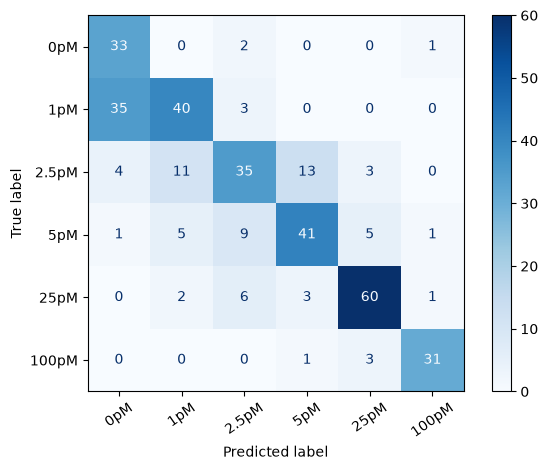

In [17]:
gated_tune_metrics = evaluate_tune(gated_model)

### 4.5 Saving artifacts

In [18]:
gated_reloaded, gated_paths = save_and_verify(
    "extended_cnn_gated_fusion", gated_model, gated_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_gated_fusion/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_gated_fusion/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_gated_fusion/metadata.json'))
reloaded extended_cnn at best epoch 67


<a id="variant-multi-scale"></a>
## 5. Multi-Scale CNN

Parallel kernels inspect the same trajectory at short, medium and long scales. This avoids forcing one sequential stack to learn every receptive field, and is attractive when sharp transitions and broad response envelopes are both informative.

```text
         ┌→ Conv k=3  → GAP ─┐
x ──────┼→ Conv k=7  → GAP ─┼→ concatenate → MLP → dose
         └→ Conv k=15 → GAP ─┘
```

### 5.1 Model generation

In [19]:
multi_scale_model, multi_scale_parameter_count = create_model(
    "multi_scale",
    **{**COMMON_MODEL_CONFIG, "multi_scale_kernel_sizes": (3, 7, 15)},
)
multi_scale_training_config = training_config(learning_rate=6e-4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'multi_scale', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 31,526


### 5.2 Training

In [20]:
multi_scale_history = fit_model(
    multi_scale_model, multi_scale_training_config
)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.62601, validation loss 1.73438, train accuracy 29.4%, validation accuracy 13.8%
epoch   5: train loss 1.27423, validation loss 1.34756, train accuracy 41.6%, validation accuracy 37.0%
epoch  10: train loss 1.15682, validation loss 1.20450, train accuracy 47.1%, validation accuracy 47.6%
epoch  15: train loss 1.09569, validation loss 1.16064, train accuracy 50.5%, validation accuracy 49.6%
epoch  20: train loss 1.09293, validation loss 1.09550, train accuracy 50.5%, validation accuracy 51.0%
epoch  25: train loss 1.06387, validation loss 1.08842, train accuracy 52.4%, validation accuracy 51.3%
epoch  30: train loss 1.04177, validation loss 1.08049, train accuracy 53.3%, validation accuracy 50.7%
epoch  35: 

### 5.3 History analysis

A competitive tune score with fewer parameters would support the explicit scale prior. Underfitting suggests that one convolution per scale is too shallow rather than that multi-scale processing is unhelpful.

{'epochs_run': 140, 'best_epoch': 136, 'training_loss': 0.9155255110887643, 'tune_loss': 0.9209127784800051, 'training_accuracy': 0.5982078853046595, 'tune_accuracy': 0.5873925501432665, 'accuracy_gap': 0.010815335161392992}


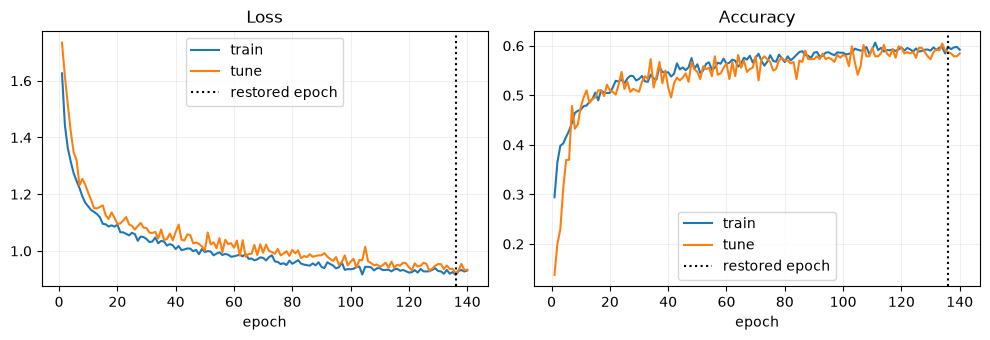

In [21]:
multi_scale_summary = analyze_history(multi_scale_history)

### 5.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.38      0.69      0.49        36
         1pM       0.64      0.50      0.56        78
       2.5pM       0.56      0.42      0.48        66
         5pM       0.47      0.50      0.48        62
        25pM       0.75      0.68      0.72        72
       100pM       0.80      0.94      0.87        35

    accuracy                           0.59       349
   macro avg       0.60      0.62      0.60       349
weighted avg       0.61      0.59      0.59       349



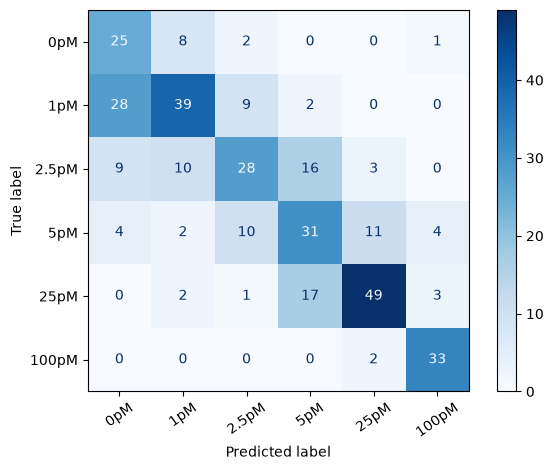

In [22]:
multi_scale_tune_metrics = evaluate_tune(multi_scale_model)

### 5.5 Saving artifacts

In [23]:
multi_scale_reloaded, multi_scale_paths = save_and_verify(
    "extended_cnn_multi_scale", multi_scale_model, multi_scale_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_multi_scale/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_multi_scale/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_multi_scale/metadata.json'))
reloaded extended_cnn at best epoch 136


<a id="variant-tcn"></a>
## 6. Temporal Convolutional Network (TCN)

Residual convolutions with exponentially increasing dilation enlarge the receptive field without repeatedly downsampling the trajectory. The TCN can relate distant time points while retaining the optimization advantages of convolutional residual blocks.

```text
x → 1×1 projection → ResConv(d=1) → ResConv(d=2) → ResConv(d=4) → GAP → MLP
```

### 6.1 Model generation

In [24]:
tcn_model, tcn_parameter_count = create_model(
    "tcn", **{**COMMON_MODEL_CONFIG, "branch_channels": (16, 32, 48)}
)
tcn_training_config = training_config(learning_rate=4e-4, weight_decay=7e-4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'tcn', 'branch_channels': (16, 32, 48), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 136,294


### 6.2 Training

In [25]:
tcn_history = fit_model(tcn_model, tcn_training_config)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0004, weight_decay=0.0007, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.63918, validation loss 1.74393, train accuracy 29.7%, validation accuracy 28.4%
epoch   5: train loss 1.19144, validation loss 1.22942, train accuracy 48.9%, validation accuracy 48.7%
epoch  10: train loss 1.03258, validation loss 1.05525, train accuracy 57.2%, validation accuracy 56.2%
epoch  15: train loss 0.92965, validation loss 1.00436, train accuracy 61.5%, validation accuracy 56.4%
epoch  20: train loss 0.89779, validation loss 0.94680, train accuracy 62.2%, validation accuracy 58.5%
epoch  25: train loss 0.86476, validation loss 0.94614, train accuracy 64.8%, validation accuracy 58.2%
epoch  30: train loss 0.82367, validation loss 0.93261, train accuracy 65.6%, validation accuracy 60.7%
epoch  35: 

### 6.3 History analysis

If long-range context matters, the TCN should improve tune performance without needing a very wide dense head. Strong train performance with weak tune performance calls for a narrower TCN or stronger dropout.

{'epochs_run': 69, 'best_epoch': 49, 'training_loss': 0.7284735116907345, 'tune_loss': 0.7777385578456103, 'training_accuracy': 0.6949820788530466, 'tune_accuracy': 0.6790830945558739, 'accuracy_gap': 0.015898984297172736}


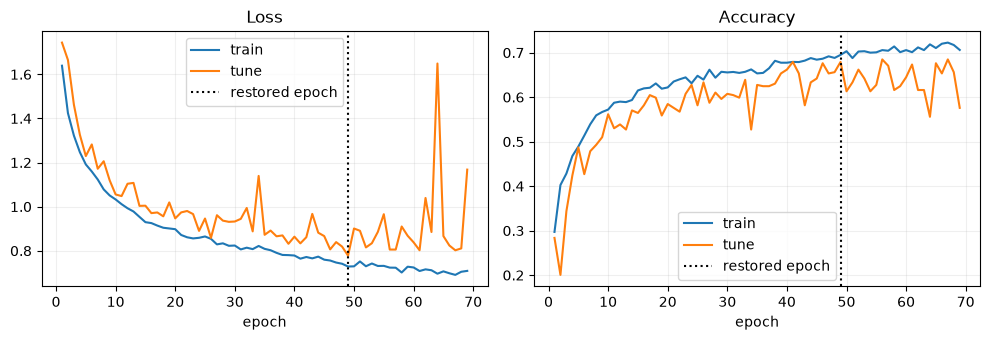

In [26]:
tcn_summary = analyze_history(tcn_history)

### 6.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.72      0.55        36
         1pM       0.62      0.53      0.57        78
       2.5pM       0.65      0.64      0.64        66
         5pM       0.73      0.53      0.62        62
        25pM       0.82      0.86      0.84        72
       100pM       0.85      0.94      0.89        35

    accuracy                           0.68       349
   macro avg       0.69      0.70      0.69       349
weighted avg       0.69      0.68      0.68       349



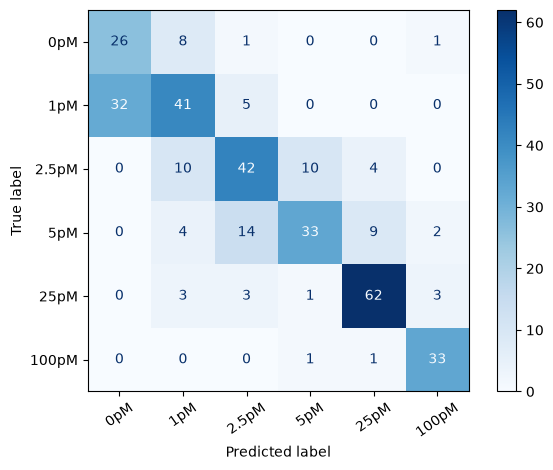

In [27]:
tcn_tune_metrics = evaluate_tune(tcn_model)

### 6.5 Saving artifacts

In [28]:
tcn_reloaded, tcn_paths = save_and_verify(
    "extended_cnn_tcn", tcn_model, tcn_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_tcn/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_tcn/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_tcn/metadata.json'))
reloaded extended_cnn at best epoch 49


<a id="variant-shift-robust"></a>
## 7. Shift-robust CNN

Stride-one, length-preserving convolutions avoid anchoring features to an early downsampling grid. Global average pooling then summarizes whether a motif occurred, with less dependence on its exact position. This provides approximate—not exact—shift invariance; random temporal-shift augmentation would strengthen it further.

```text
x → same-length Conv blocks (stride 1) → global average over time → MLP → dose
```

### 7.1 Model generation

In [29]:
shift_robust_model, shift_robust_parameter_count = create_model(
    "shift_robust", **COMMON_MODEL_CONFIG
)
shift_robust_training_config = training_config(learning_rate=6e-4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'shift_robust', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 37,014


### 7.2 Training

In [30]:
shift_robust_history = fit_model(
    shift_robust_model, shift_robust_training_config
)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.62382, validation loss 1.79700, train accuracy 26.1%, validation accuracy 22.1%
epoch   5: train loss 1.24001, validation loss 1.42141, train accuracy 44.6%, validation accuracy 33.8%
epoch  10: train loss 1.10928, validation loss 1.28687, train accuracy 50.9%, validation accuracy 40.7%
epoch  15: train loss 1.03674, validation loss 1.19441, train accuracy 54.6%, validation accuracy 48.1%
epoch  20: train loss 1.02020, validation loss 1.16770, train accuracy 54.9%, validation accuracy 45.0%
epoch  25: train loss 0.98191, validation loss 1.21228, train accuracy 58.4%, validation accuracy 45.8%
epoch  30: train loss 0.96440, validation loss 1.07429, train accuracy 55.6%, validation accuracy 52.4%
epoch  35: 

### 7.3 History analysis

Improvement would suggest that exact event timing varies across cells. If performance drops, absolute timing is probably discriminative or global averaging removes too much temporal structure.

{'epochs_run': 80, 'best_epoch': 60, 'training_loss': 0.8910720950813704, 'tune_loss': 0.9679924447761907, 'training_accuracy': 0.610752688172043, 'tune_accuracy': 0.5587392550143266, 'accuracy_gap': 0.05201343315771634}


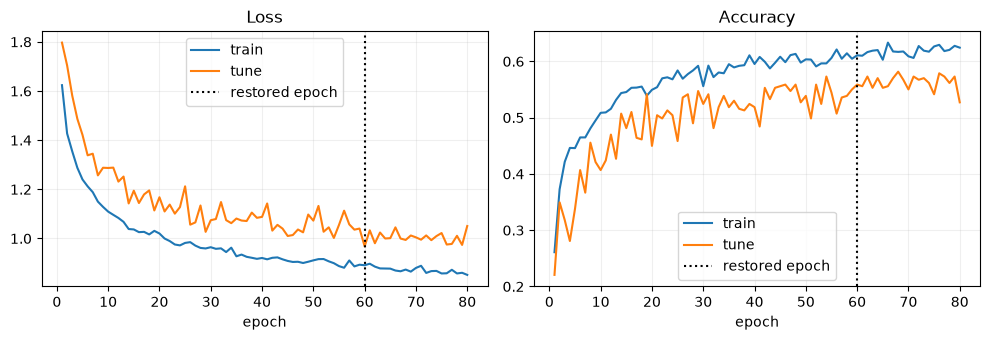

In [31]:
shift_robust_summary = analyze_history(shift_robust_history)

### 7.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.44      0.78      0.56        36
         1pM       0.58      0.53      0.55        78
       2.5pM       0.52      0.48      0.50        66
         5pM       0.55      0.42      0.48        62
        25pM       0.69      0.47      0.56        72
       100pM       0.61      0.97      0.75        35

    accuracy                           0.56       349
   macro avg       0.56      0.61      0.57       349
weighted avg       0.57      0.56      0.55       349



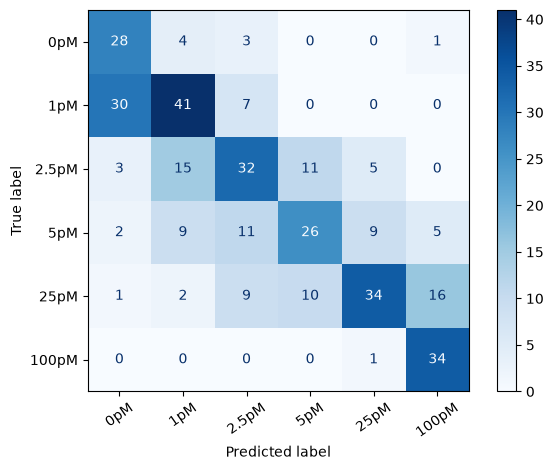

In [32]:
shift_robust_tune_metrics = evaluate_tune(shift_robust_model)

### 7.5 Saving artifacts

In [33]:
shift_robust_reloaded, shift_robust_paths = save_and_verify(
    "extended_cnn_shift_robust", shift_robust_model, shift_robust_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_shift_robust/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_shift_robust/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_shift_robust/metadata.json'))
reloaded extended_cnn at best epoch 60


<a id="variant-ordinal"></a>
## 8. Ordinal classification

Dose labels are numerically ordered. The model therefore predicts one latent dose score and compares it with learned class centers that are constrained to remain ordered. Cross-entropy still trains the resulting class logits, so this head works with the shared trainer. The useful bias is that confusing neighboring doses is geometrically easier than jumping across the entire dose range.

```text
x → CNN → scalar score s
ordered centers c₀ < c₁ < … < cₖ → logits[j] = −(s−cⱼ)² / temperature
```

### 8.1 Model generation

In [ ]:
ordinal_model, ordinal_parameter_count = create_model(
    "ordinal", **{**COMMON_MODEL_CONFIG, "ordinal_temperature": 0.8}
)
ordinal_training_config = training_config(learning_rate=4e-4, weight_decay=7e-4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'ordinal', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 0.8}
trainable parameters: 65,815


### 8.2 Training

In [35]:
ordinal_history = fit_model(ordinal_model, ordinal_training_config)

training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0004, weight_decay=0.0007, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.60227, validation loss 1.67114, train accuracy 30.7%, validation accuracy 22.1%
epoch   5: train loss 1.18751, validation loss 1.39257, train accuracy 41.6%, validation accuracy 35.2%
epoch  10: train loss 1.14571, validation loss 1.38036, train accuracy 43.8%, validation accuracy 35.2%
epoch  15: train loss 1.12418, validation loss 1.32250, train accuracy 44.3%, validation accuracy 39.0%
epoch  20: train loss 1.12048, validation loss 1.30207, train accuracy 45.2%, validation accuracy 41.3%
epoch  25: train loss 1.11756, validation loss 1.28480, train accuracy 43.8%, validation accuracy 43.6%
epoch  30: train loss 1.09644, validation loss 1.28671, train accuracy 46.8%, validation accuracy 43.3%
epoch  35: 

### 8.3 History analysis

The ordinal bias is helpful if most residual errors move toward adjacent doses and macro-F1 remains competitive. It can underfit when time-course phenotypes are not monotonic in dose, despite the numerical label order.

{'epochs_run': 140, 'best_epoch': 137, 'training_loss': 0.9981390518954151, 'tune_loss': 1.1950679330907783, 'training_accuracy': 0.5186379928315412, 'tune_accuracy': 0.498567335243553, 'accuracy_gap': 0.020070657587988205}


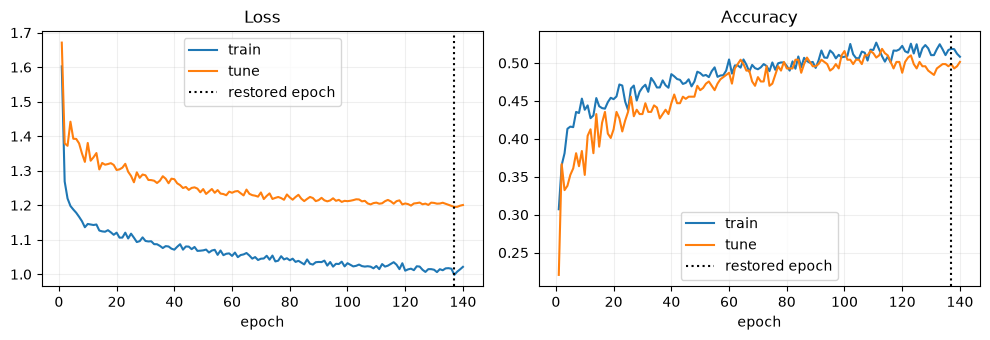

In [36]:
ordinal_summary = analyze_history(ordinal_history)

### 8.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.33      0.92      0.48        36
         1pM       0.52      0.17      0.25        78
       2.5pM       0.54      0.61      0.57        66
         5pM       0.41      0.32      0.36        62
        25pM       0.73      0.50      0.60        72
       100pM       0.63      0.91      0.74        35

    accuracy                           0.50       349
   macro avg       0.53      0.57      0.50       349
weighted avg       0.54      0.50      0.48       349



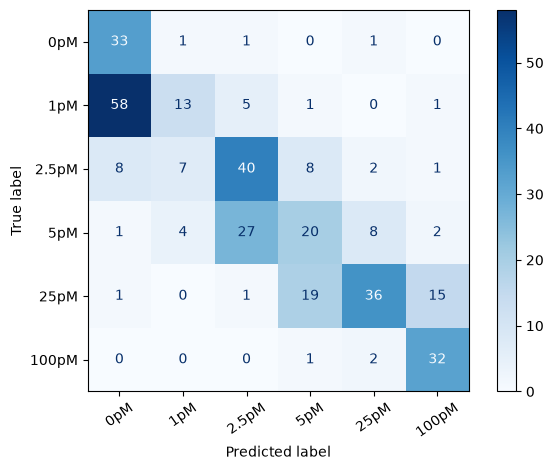

In [37]:
ordinal_tune_metrics = evaluate_tune(ordinal_model)

### 8.5 Saving artifacts

In [38]:
ordinal_reloaded, ordinal_paths = save_and_verify(
    "extended_cnn_ordinal", ordinal_model, ordinal_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_ordinal/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_ordinal/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/extended_cnn_ordinal/metadata.json'))
reloaded extended_cnn at best epoch 137


<a id="direct-comparison"></a>
## 9. Direct comparison

Prefer the smallest variant whose tune macro-F1 and tune loss are competitive. Accuracy alone can hide a model that ignores difficult doses. The ordinal model should additionally be inspected for whether its remaining errors are predominantly between neighboring doses.

In [39]:
comparison = pd.DataFrame([
    {"variant": "first_difference", "parameters": first_difference_parameter_count, **first_difference_summary, **first_difference_tune_metrics},
    {"variant": "fft", "parameters": fft_parameter_count, **fft_summary, **fft_tune_metrics},
    {"variant": "gated_fusion", "parameters": gated_parameter_count, **gated_summary, **gated_tune_metrics},
    {"variant": "multi_scale", "parameters": multi_scale_parameter_count, **multi_scale_summary, **multi_scale_tune_metrics},
    {"variant": "tcn", "parameters": tcn_parameter_count, **tcn_summary, **tcn_tune_metrics},
    {"variant": "shift_robust", "parameters": shift_robust_parameter_count, **shift_robust_summary, **shift_robust_tune_metrics},
    {"variant": "ordinal", "parameters": ordinal_parameter_count, **ordinal_summary, **ordinal_tune_metrics},
]).set_index("variant")
comparison.round(4)

,parameters,epochs_run,best_epoch,training_loss,tune_loss,training_accuracy,tune_accuracy,accuracy_gap,tune_macro_f1
variant,,,,,,,,,
first_difference,127174,86,66,0.5598,0.7143,0.7520,0.6848,0.0672,0.6933
fft,188374,110,90,0.6289,0.7544,0.7602,0.6734,0.0869,0.6836
gated_fusion,225734,87,67,0.5462,0.7255,0.7620,0.6877,0.0743,0.6989
multi_scale,31526,140,136,0.9155,0.9209,0.5982,0.5874,0.0108,0.6004
tcn,136294,69,49,0.7285,0.7777,0.6950,0.6791,0.0159,0.6851
shift_robust,37014,80,60,0.8911,0.9680,0.6108,0.5587,0.0520,0.5661
ordinal,65815,140,137,0.9981,1.1951,0.5186,0.4986,0.0201,0.5009


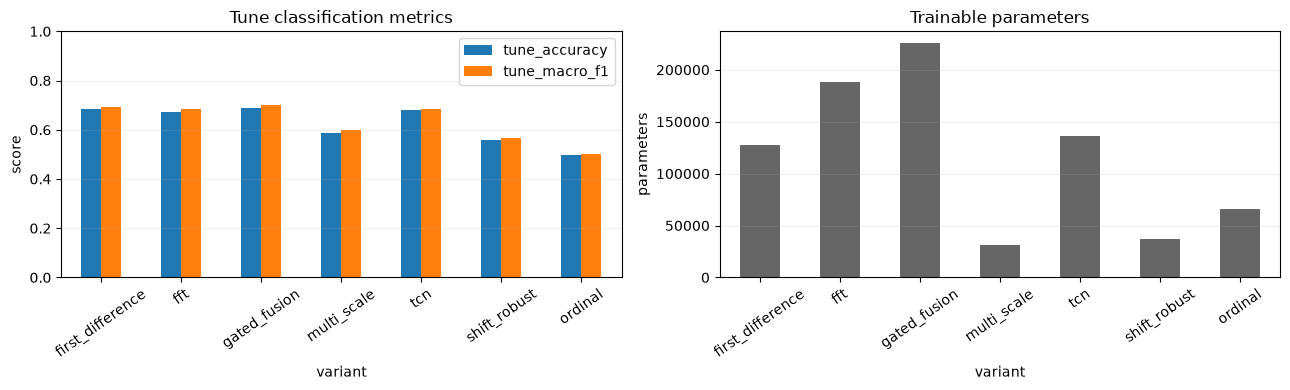

In [40]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4))
comparison[["tune_accuracy", "tune_macro_f1"]].plot.bar(
    ax=axes[0], ylim=(0, 1), rot=35
)
axes[0].set(title="Tune classification metrics", ylabel="score")
comparison["parameters"].plot.bar(ax=axes[1], color="0.4", rot=35)
axes[1].set(title="Trainable parameters", ylabel="parameters")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

### Interpretation and next steps

The comparison separates representational assumptions from simple model size. First-Difference is the main reference; FFT tests frequency information, gated fusion tests adaptive representation mixing, Multi-Scale and TCN test temporal context, Shift-Robust tests timing variability, and Ordinal tests whether the dose order is a useful constraint. A variant is convincing only when its tune macro-F1 improves across several seeds without a widening train–tune gap.

For the next iteration, repeat the candidates with several seeds and compare mean and standard deviation. For gated fusion, inspect the gate distribution; for Multi-Scale, ablate individual kernel sizes; for TCN, vary dilation depth; for Shift-Robust, evaluate deliberately shifted tune trajectories; and for Ordinal, report mean absolute class-index error in addition to macro-F1. Keep test untouched until the architecture and hyperparameters are frozen.

<a id="training-history-comparison"></a>
## 10. Training-history comparison

The four panels compare train and tune loss and accuracy for all seven variants. Each dot marks the checkpoint epoch restored after early stopping. This is one combined figure; the earlier history cells are per-model diagnostic plots.

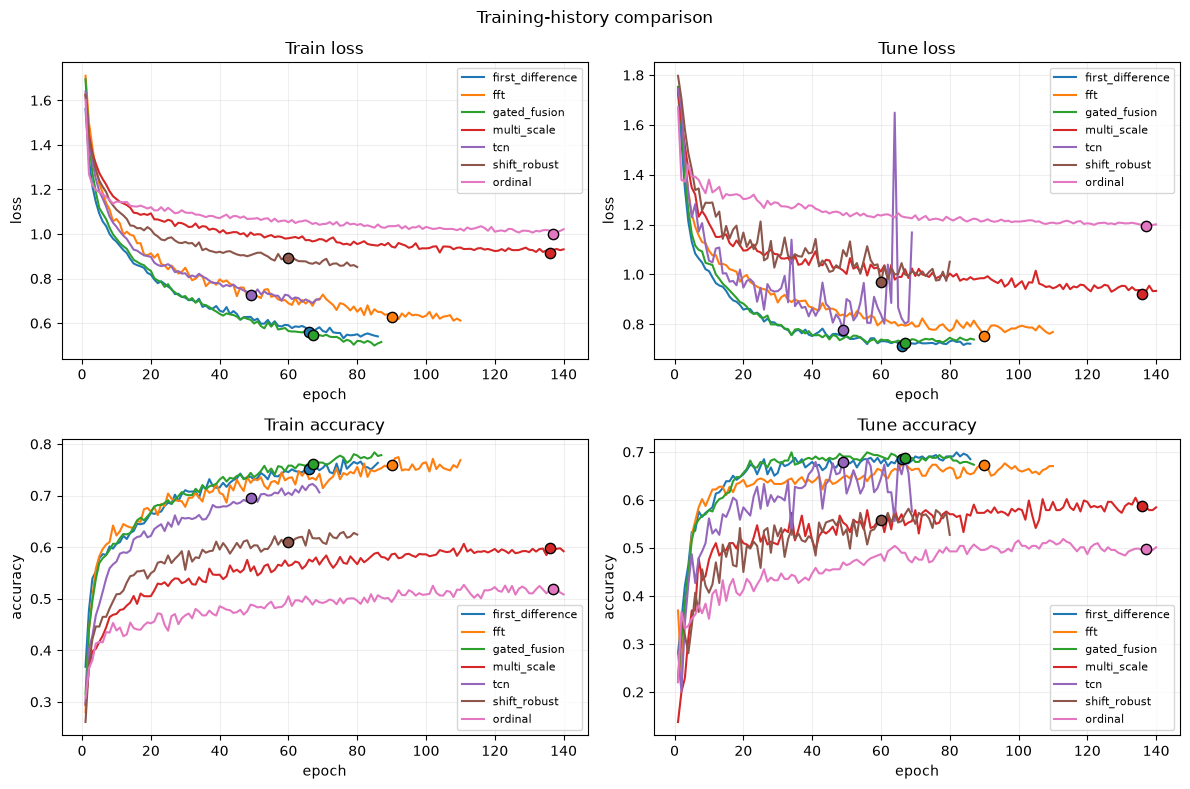

In [41]:
history_comparison_figure = plot_history_comparison({
    "first_difference": first_difference_history,
    "fft": fft_history,
    "gated_fusion": gated_history,
    "multi_scale": multi_scale_history,
    "tcn": tcn_history,
    "shift_robust": shift_robust_history,
    "ordinal": ordinal_history,
})